In [1]:
import pandas as pd
import numpy as np
import mlflow
import mlflow.sklearn
import mlflow.xgboost
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, f1_score, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
)
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

In [2]:
# Cell 2 — Load Splits
X_train = pd.read_csv('processed/X_train.csv')
X_val   = pd.read_csv('processed/X_val.csv')
X_test  = pd.read_csv('processed/X_test.csv')
y_train = pd.read_csv('processed/y_train.csv').squeeze()
y_val   = pd.read_csv('processed/y_val.csv').squeeze()
y_test  = pd.read_csv('processed/y_test.csv').squeeze()

print("Loaded all splits successfully")

Loaded all splits successfully


In [3]:
# Cell 3 — Baseline: Logistic Regression
mlflow.set_experiment("loan-default")

with mlflow.start_run(run_name="logistic_regression"):
    lr = LogisticRegression(max_iter=1000, random_state=42)
    lr.fit(X_train, y_train)

    val_preds = lr.predict(X_val)
    val_probs = lr.predict_proba(X_val)[:, 1]

    auc = roc_auc_score(y_val, val_probs)
    f1  = f1_score(y_val, val_preds)

    mlflow.log_param("model", "logistic_regression")
    mlflow.log_metric("val_auc", auc)
    mlflow.log_metric("val_f1", f1)
    mlflow.sklearn.log_model(lr, "model")

    print(f"Logistic Regression — AUC: {auc:.4f} | F1: {f1:.4f}")
    print(classification_report(y_val, val_preds))

C:\Users\adity\anaconda3\envs\loanproject\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
2026/03/25 01:15:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/25 01:15:03 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe al

Logistic Regression — AUC: 0.7020 | F1: 0.1149
              precision    recall  f1-score   support

           0       0.81      0.98      0.89    146913
           1       0.51      0.06      0.11     36106

    accuracy                           0.80    183019
   macro avg       0.66      0.52      0.50    183019
weighted avg       0.75      0.80      0.74    183019



In [4]:
# Cell 4 — Main Model: LightGBM
import lightgbm as lgb

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
ratio = neg / pos

with mlflow.start_run(run_name="lightgbm_baseline"):
    model = lgb.LGBMClassifier (
        n_estimators=500,
        max_depth=8,
        learning_rate=0.03,
        num_leaves=50,
        min_child_samples=20,
        scale_pos_weight=ratio,
        colsample_bytree=0.8,
        subsample=0.8,
        random_state=42
    )
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
    )

    val_preds = model.predict(X_val)
    val_probs = model.predict_proba(X_val)[:, 1]

    auc = roc_auc_score(y_val, val_probs)
    f1  = f1_score(y_val, val_preds)

    mlflow.log_metric("val_auc", auc)
    mlflow.log_metric("val_f1", f1)

    print(f"LightGBM — AUC: {auc:.4f} | F1: {f1:.4f}")
    print(classification_report(y_val, val_preds))


[LightGBM] [Info] Number of positive: 168495, number of negative: 685593
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003758 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1714
[LightGBM] [Info] Number of data points in the train set: 854088, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.197281 -> initscore=-1.403378
[LightGBM] [Info] Start training from score -1.403378
LightGBM — AUC: 0.7176 | F1: 0.4288
              precision    recall  f1-score   support

           0       0.89      0.63      0.74    146913
           1       0.31      0.68      0.43     36106

    accuracy                           0.64    183019
   macro avg       0.60      0.66      0.58    183019
weighted avg       0.78      0.64      0.68    183019



=== FINAL TEST RESULTS ===
AUC-ROC: 0.7159
F1:      0.4267
              precision    recall  f1-score   support

           0       0.89      0.63      0.74    146913
           1       0.31      0.68      0.43     36107

    accuracy                           0.64    183020
   macro avg       0.60      0.65      0.58    183020
weighted avg       0.77      0.64      0.68    183020



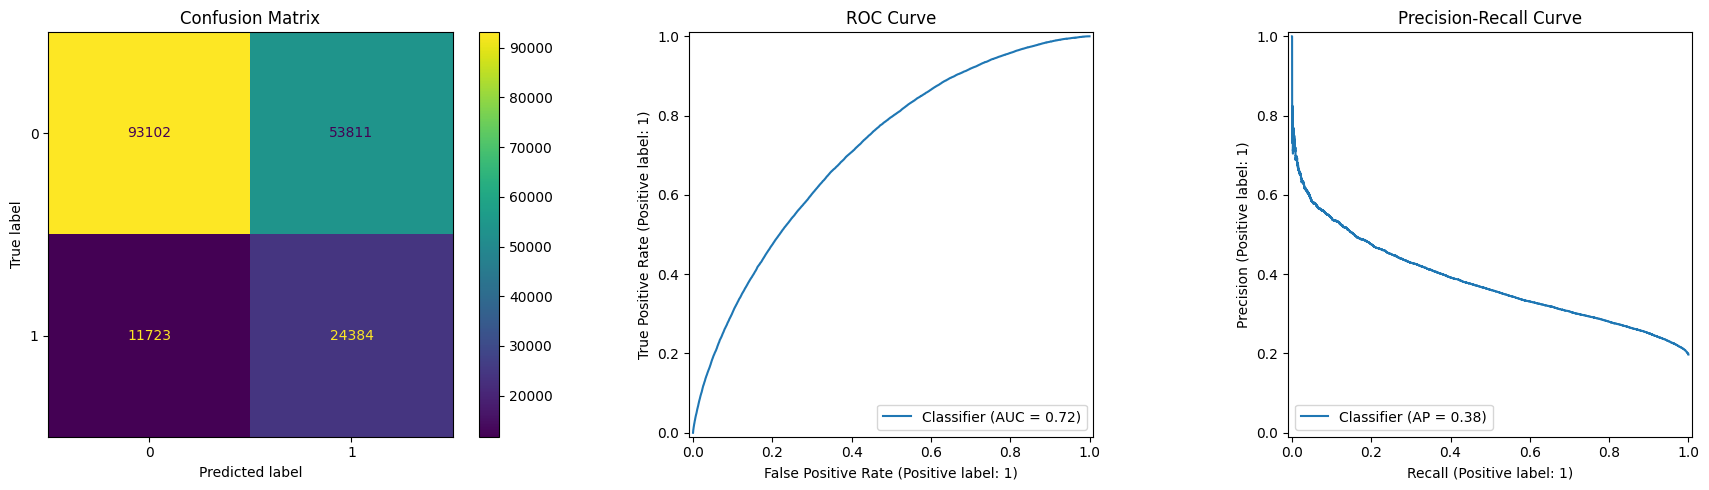

In [5]:
# Evaluate on Test Set
test_preds = model.predict(X_test)
test_probs = model.predict_proba(X_test)[:, 1]

print("=== FINAL TEST RESULTS ===")
print(f"AUC-ROC: {roc_auc_score(y_test, test_probs):.4f}")
print(f"F1:      {f1_score(y_test, test_preds):.4f}")
print(classification_report(y_test, test_preds))

# Plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ConfusionMatrixDisplay.from_predictions(y_test, test_preds, ax=axes[0])
axes[0].set_title("Confusion Matrix")

RocCurveDisplay.from_predictions(y_test, test_probs, ax=axes[1])
axes[1].set_title("ROC Curve")

PrecisionRecallDisplay.from_predictions(y_test, test_probs, ax=axes[2])
axes[2].set_title("Precision-Recall Curve")

plt.tight_layout()
plt.show()

In [6]:
import joblib
joblib.dump(model, 'processed/lgbm_model.pkl')
print("Model saved")

Model saved
